# 1. Contexto de negocio y objetivo

Este notebook analiza un caso de pricing crediticio para solicitudes de crédito vehicular ya aprobadas. La pregunta central no es si el cliente debe aprobarse, sino qué tasa APR/TEA debería ofrecerse para equilibrar probabilidad de aceptación y rentabilidad aproximada.

La variable objetivo es `Funded`: toma valor 1 cuando la solicitud aprobada fue financiada/aceptada por el cliente y 0 cuando no fue financiada/no aceptada. Por lo tanto, el modelo se interpreta como un modelo de propensión a la aceptación/adquisición del crédito, no como un modelo de riesgo crediticio ni de default.

El objetivo del proyecto es conectar EDA, probabilidad de adquisición, spread y optimización de tasa para apoyar decisiones de Pricing y luego habilitar acciones comerciales desde CRM/canales.


# 2. Ubicación del análisis en el flujo bancario: Riesgos → Pricing → CRM/campañas

El caso se ubica dentro de un flujo bancario donde Riesgos, Pricing y CRM cumplen roles distintos. La base utilizada contiene solicitudes de crédito ya aprobadas, por lo que el análisis no busca decidir aprobación crediticia, default ni pérdida esperada.

En este flujo, Riesgos aporta variables como score, `Tier`, monto, plazo y perfil del cliente. Pricing utiliza esa información para definir una tasa APR/TEA y evaluar el equilibrio entre probabilidad de aceptación y rentabilidad aproximada. Finalmente, los resultados podrían ser usados por CRM o canales comerciales para pilotos, campañas o acciones diferenciadas por segmento.


# Bibliotecas


In [137]:
# Bibliotecas para estructura de datos y operaciones matemáticas
import pandas as pd
import numpy as np
from datetime import date
from datetime import datetime

# Modelamiento
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, \
  recall_score, ConfusionMatrixDisplay

# Bibliotecas para gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

# 3. Carga, lectura inicial y calidad de datos


In [138]:
df = pd.read_csv("AutoLoanData.csv")
df.head(5)

,Funded,Tier,Partner,Term,CarType,FICO,Amount,APR,PrimeRate,State
0,0,3,1,72,N,695,35000.0,7.49,1.8388,TX
1,0,1,3,60,N,751,40000.0,5.49,1.8388,VA
2,0,1,3,60,N,731,18064.0,5.49,1.8388,GA
3,0,7,3,72,N,652,15415.0,8.99,1.8388,MN
4,0,1,1,48,N,730,32000.0,5.49,1.8388,SC


### Lectura inicial de la base

La vista inicial confirma qué cada registro combina información de aceptación (`Funded`), perfil crediticio (`Tier`, `FICO`), condiciones comerciales (`APR`, `PrimeRate`, `Term`, `Amount`) y atributos de origen o segmento (`Partner`, `CarType`, `State`). Esto es consistente con un problema de pricing posterior a la aprobación: la institucion ya aprobo al cliente, y ahora observa si acepta la oferta.


### Revisión inicial de estructura y distribución


In [139]:
## Revisando la estructura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152963 entries, 0 to 152962
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Funded     152963 non-null  int64  
 1   Tier       152963 non-null  int64  
 2   Partner    152963 non-null  int64  
 3   Term       152963 non-null  int64  
 4   CarType    152963 non-null  object 
 5   FICO       152963 non-null  int64  
 6   Amount     152963 non-null  float64
 7   APR        152963 non-null  float64
 8   PrimeRate  152963 non-null  float64
 9   State      152963 non-null  object 
dtypes: float64(3), int64(5), object(2)
memory usage: 11.7+ MB


In [140]:
df.describe()
## Se evidencia las variaciones de cada una de las variables

,Funded,Tier,Partner,Term,FICO,Amount,APR,PrimeRate
count,152963.000000,152963.000000,152963.000000,152963.000000,152963.000000,152963.000000,152963.000000,152963.000000
mean,0.172081,2.270523,2.039846,58.031485,727.342076,28551.561702,5.476666,1.325602
std,0.377452,1.863509,0.928302,10.532047,45.430759,10790.758665,1.524786,0.248339
min,0.000000,1.000000,1.000000,36.000000,594.000000,4770.000000,2.450000,1.020000
25%,0.000000,1.000000,1.000000,48.000000,691.000000,20848.000000,4.390000,1.110000
50%,0.000000,2.000000,2.000000,60.000000,727.000000,28000.000000,4.930000,1.307500
75%,0.000000,3.000000,3.000000,60.000000,764.000000,35000.000000,6.090000,1.386900
max,1.000000,7.000000,3.000000,72.000000,854.000000,100000.000000,13.900000,2.101000


### Calidad y estructura de datos

La base cargada contiene 152,963 solicitudes y 10 variables iniciales. Luego, el notebook construye variables transformadas como `LogAmount`, `Spread`, `FICOH` y `Region` según el flujo de análisis.

No se observan valores nulos en `df.info()`. La tasa de aceptación observada es 17.21% (`Funded` promedio = 0.1721), por lo qué la mayoria de solicitudes aprobadas no termina financiada.

En términos de pricing, esto refuerza qué el problema no es unicamente de elegibilidad crediticia. La institucion ya aprobo al cliente, pero la oferta debe competir con la disposición de pago, alternativas del mercado y sensibilidad a tasa.

El resumen descriptivo muestra rangos relevantes para la simulación: `APR` va de 2.45 a 13.90, `PrimeRate` de 1.02 a 2.101, `FICO` de 594 a 854 y `Amount` de 4,770 a 100,000. Estos rangos delimitan el espacio histórico observado sobre el cual se interpreta el modelo.


# 4. Unidad de análisis y variables principales

La unidad de análisis es una solicitud de crédito vehicular aprobada. Desde ese punto del funnel, el evento observado es la aceptación o no aceptación de la oferta de tasa.

| Variable | Interpretación de negocio |
|---|---|
| `Funded` | Variable objetivo: 1 si la solicitud fue financiada/aceptada y 0 si no fue financiada/no aceptada. |
| `Tier` | Clasificación de riesgo crediticio del solicitante. Se usa como segmentación de solvencia, pero el objetivo del notebook sigue siendo pricing/adquisición. |
| `Partner` | Canal o fuente de origen de la solicitud. Puede capturar diferencias comerciales en la propensión de aceptación. |
| `Term` | Plazo aprobado del préstamo en meses. Se transforma luego en categorías de plazo. |
| `CarType` | Tipo de vehículo: nuevo (`N`) o usado (`U`). |
| `FICO` | Score crediticio del solicitante. |
| `Amount` | Monto aprobado del préstamo. |
| `APR` | Tasa ofrecida/cotizada al cliente. Es la variable clave de pricing. |
| `PrimeRate` | Tasa de referencia/fondeo usada como base para aproximar el spread. |
| `State` | Estado del solicitante, posteriormente agrupado en `Region`. |

La distinción clave es qué variables como `Tier` y `FICO` describen riesgo/solvencia, mientras qué `APR`, `Spread` y la probabilidad de aceptación se usan para decisiones de pricing.


# 5. EDA orientado a pricing

El EDA se orienta a entender la base aprobada desde una lógica comercial y de pricing: tasa ofrecida (`APR`), costo/fondeo (`PrimeRate`), spread aproximado, monto, plazo, score, tier, canal, tipo de vehículo y region.

El hallazgo central es qué la aceptación no es automática despues de la aprobación. Con una tasa de aceptación cercana a 17.21%, el reto de negocio está en mejorar la decisión de tasa y priorizar segmentos donde exista mejor balance entre probabilidad de adquisición y margen esperado.


# 6. Ingeniería de características: LogAmount, Spread, FICOH, plazo y region


In [141]:
# Importe transformado a logaritmo natural
df['LogAmount'] = np.log(df['Amount'])
df['LogAmount'].describe()

count    152963.000000
mean         10.180103
std           0.420179
min           8.470102
25%           9.945013
50%          10.239960
75%          10.463103
max          11.512925
Name: LogAmount, dtype: float64

In [142]:
# Spread de la operación
df['Spread'] = df['APR']-df['PrimeRate']
df['Spread'].describe()
## Se evidencia que el spread está desde 0.94 hasta 12.8

count    152963.000000
mean          4.151064
std           1.506854
min           0.940000
25%           3.070000
50%           3.615000
75%           4.790000
max          12.800000
Name: Spread, dtype: float64

In [143]:
# Cálculo de FICOH
# Applicant’s FICO score relative to the mean FICO score for the applicant’s tier group (/100)
# El FICOH es una medida transforada que nos indica que tanto % varía el Fico (score) con respecto al fico promedio del nivel en el que se encuentra.
mean_FICO = df.groupby('Tier')['FICO'].mean().reset_index()
mean_FICO

,Tier,FICO
0,1,765.452450
1,2,713.049833
2,3,687.263306
3,7,655.864359


In [144]:
### Se calcula por cada nivel del cliente el score - el score promedio
FICO_relativo_abs =  df.apply(lambda x: x['FICO'] - mean_FICO[mean_FICO['Tier']==x['Tier']].iloc[0]['FICO'], axis=1)
FICO_relativo_pct = FICO_relativo_abs/100
df['FICOH'] = FICO_relativo_pct.round(2)

In [145]:
df['FICOH'].describe()

count    152963.000000
mean          0.002654
std           0.206067
min          -1.710000
25%          -0.110000
50%           0.000000
75%           0.110000
max           1.530000
Name: FICOH, dtype: float64

### Variables transformadas: `LogAmount`, `Spread` y `FICOH`

`LogAmount` transforma el monto aprobado para reducir asimetría y permitir qué el modelo capture efectos proporcionales del tamaño del crédito.

`Spread = APR - PrimeRate` representa una aproximación del margen financiero de la operación. En la muestra, el spread va de 0.94 a 12.80, con promedio de 4.15. Esta variable no debe interpretarse como rentabilidad neta completa: no incluye pérdida esperada, costos operativos, costo de capital ni otras cargas económicas.

`FICOH` mide el FICO relativo frente al promedio del `Tier` del solicitante. Esto ayuda a distinguir riesgo absoluto (`FICO`) de posición relativa dentro del segmento de solvencia. Los promedios por `Tier` son consistentes con la jerarquía de riesgo: Tier 1 tiene FICO promedio 765.45, Tier 2 713.05, Tier 3 687.26 y Tier 7 655.86.


In [146]:
# Categorización del plazo
## Para este caso se trabaja como una variable nominal
sorted(df['Term'].unique())

[np.int64(36), np.int64(48), np.int64(60), np.int64(66), np.int64(72)]

In [147]:
## Se le hace una conversión y se le asigna una etiqueta
df['Term'] = df.apply(lambda x: '36' if x['Term']==36
                      else '48' if x['Term']==48
                      else '60' if x['Term']==60
                      else '66+', axis=1)

In [148]:
df['Term'].value_counts()

Term
60     81156
66+    33231
48     20852
36     17724
Name: count, dtype: int64

In [149]:
# Regiones
# Northeast
lst_1 = ['CT', 'MA', 'ME', 'NH', 'NJ', 'NY', 'PA', 'RI', 'VT']
dict_1 = dict.fromkeys(lst_1, 1)

# Midwest
lst_2 = ['IA', 'IL', 'IN', 'KS', 'MI', 'MN', 'MO', 'ND', 'NE', 'OH', 'SD', 'WI']
dict_2 = dict.fromkeys(lst_2, 2)

# South
lst_3 = ['AL', 'AR', 'DC', 'DE', 'FL', 'GA', 'KY', 'LA', 'MD', 'MS', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA', 'WV']
dict_3 = dict.fromkeys(lst_3, 3)

# West
lst_4 = ['AK', 'AZ', 'CA', 'CO', 'HI', 'ID', 'MT', 'NM', 'NV', 'OR', 'UT', 'WA', 'WY']
dict_4 = dict.fromkeys(lst_4, 4)

# Se concatenan los dictionarios
regions = {**dict_1, **dict_2, **dict_3, **dict_4}

df['Region'] = df['State'].map(regions)

In [150]:
df['Region'].value_counts()

Region
3    61760
4    34430
1    33151
2    23622
Name: count, dtype: int64

### Transformación de plazo y region

El plazo se trata como variable nominal y se agrupa en `36`, `48`, `60` y `66+`. La mayor concentración está en 60 meses, con 81,156 registros, seguida de `66+` con 33,231. Esto es relevante porque el plazo puede afectar tanto la sensibilidad a tasa como el margen esperado.

La agrupación regional convierte `State` en cuatro regiones. La Region 3 concentra 61,760 registros, seguida por Region 4 con 34,430, Region 1 con 33,151 y Region 2 con 23,622. Estas variables permiten capturar diferencias geográficas en aceptación sin modelar cada estado por separado.


In [151]:
# Se crean variables ficticias
df_dummies = pd.get_dummies(df['Tier'], prefix='Tier')

# Convertimos los valores booleanos a enteros si es necesario
df_dummies = df_dummies.astype(int)

# Lo integramos al dataframe original
df = pd.concat([df, df_dummies], axis=1)

df.head()

,Funded,Tier,Partner,Term,CarType,FICO,Amount,APR,PrimeRate,State,LogAmount,Spread,FICOH,Region,Tier_1,Tier_2,Tier_3,Tier_7
0,0,3,1,66+,N,695,35000.0,7.49,1.8388,TX,10.463103,5.6512,0.08,3,0,0,1,0
1,0,1,3,60,N,751,40000.0,5.49,1.8388,VA,10.596635,3.6512,-0.14,3,1,0,0,0
2,0,1,3,60,N,731,18064.0,5.49,1.8388,GA,9.801676,3.6512,-0.34,3,1,0,0,0
3,0,7,3,66+,N,652,15415.0,8.99,1.8388,MN,9.643096,7.1512,-0.04,2,0,0,0,1
4,0,1,1,48,N,730,32000.0,5.49,1.8388,SC,10.373491,3.6512,-0.35,3,1,0,0,0


In [152]:
# Se crean variables ficticias
df_dummies = pd.get_dummies(df['Partner'], prefix='Partner')

# Convertimos los valores booleanos a enteros si es necesario
df_dummies = df_dummies.astype(int)

# Lo integramos al dataframe original
df = pd.concat([df, df_dummies], axis=1)

df.head()

,Funded,Tier,Partner,Term,CarType,FICO,Amount,APR,PrimeRate,State,...,Spread,FICOH,Region,Tier_1,Tier_2,Tier_3,Tier_7,Partner_1,Partner_2,Partner_3
0,0,3,1,66+,N,695,35000.0,7.49,1.8388,TX,...,5.6512,0.08,3,0,0,1,0,1,0,0
1,0,1,3,60,N,751,40000.0,5.49,1.8388,VA,...,3.6512,-0.14,3,1,0,0,0,0,0,1
2,0,1,3,60,N,731,18064.0,5.49,1.8388,GA,...,3.6512,-0.34,3,1,0,0,0,0,0,1
3,0,7,3,66+,N,652,15415.0,8.99,1.8388,MN,...,7.1512,-0.04,2,0,0,0,1,0,0,1
4,0,1,1,48,N,730,32000.0,5.49,1.8388,SC,...,3.6512,-0.35,3,1,0,0,0,1,0,0


In [153]:
# Se crean variables ficticias
df_dummies = pd.get_dummies(df['CarType'], prefix='CarType')

# Convertimos los valores booleanos a enteros si es necesario
df_dummies = df_dummies.astype(int)

# Lo integramos al dataframe original
df = pd.concat([df, df_dummies], axis=1)

df.head()

,Funded,Tier,Partner,Term,CarType,FICO,Amount,APR,PrimeRate,State,...,Region,Tier_1,Tier_2,Tier_3,Tier_7,Partner_1,Partner_2,Partner_3,CarType_N,CarType_U
0,0,3,1,66+,N,695,35000.0,7.49,1.8388,TX,...,3,0,0,1,0,1,0,0,1,0
1,0,1,3,60,N,751,40000.0,5.49,1.8388,VA,...,3,1,0,0,0,0,0,1,1,0
2,0,1,3,60,N,731,18064.0,5.49,1.8388,GA,...,3,1,0,0,0,0,0,1,1,0
3,0,7,3,66+,N,652,15415.0,8.99,1.8388,MN,...,2,0,0,0,1,0,0,1,1,0
4,0,1,1,48,N,730,32000.0,5.49,1.8388,SC,...,3,1,0,0,0,1,0,0,1,0


In [154]:
# Se crean variables ficticias
df_dummies = pd.get_dummies(df['Term'], prefix='Term')

# Convertimos los valores booleanos a enteros si es necesario
df_dummies = df_dummies.astype(int)

# Lo integramos al dataframe original
df = pd.concat([df, df_dummies], axis=1)

df.head()

,Funded,Tier,Partner,Term,CarType,FICO,Amount,APR,PrimeRate,State,...,Tier_7,Partner_1,Partner_2,Partner_3,CarType_N,CarType_U,Term_36,Term_48,Term_60,Term_66+
0,0,3,1,66+,N,695,35000.0,7.49,1.8388,TX,...,0,1,0,0,1,0,0,0,0,1
1,0,1,3,60,N,751,40000.0,5.49,1.8388,VA,...,0,0,0,1,1,0,0,0,1,0
2,0,1,3,60,N,731,18064.0,5.49,1.8388,GA,...,0,0,0,1,1,0,0,0,1,0
3,0,7,3,66+,N,652,15415.0,8.99,1.8388,MN,...,1,0,0,1,1,0,0,0,0,1
4,0,1,1,48,N,730,32000.0,5.49,1.8388,SC,...,0,1,0,0,1,0,0,1,0,0


In [155]:
# Se crean variables ficticias
df_dummies = pd.get_dummies(df['Region'], prefix='Region')

# Convertimos los valores booleanos a enteros si es necesario
df_dummies = df_dummies.astype(int)

# Lo integramos al dataframe original
df = pd.concat([df, df_dummies], axis=1)

df.head()

,Funded,Tier,Partner,Term,CarType,FICO,Amount,APR,PrimeRate,State,...,CarType_N,CarType_U,Term_36,Term_48,Term_60,Term_66+,Region_1,Region_2,Region_3,Region_4
0,0,3,1,66+,N,695,35000.0,7.49,1.8388,TX,...,1,0,0,0,0,1,0,0,1,0
1,0,1,3,60,N,751,40000.0,5.49,1.8388,VA,...,1,0,0,0,1,0,0,0,1,0
2,0,1,3,60,N,731,18064.0,5.49,1.8388,GA,...,1,0,0,0,1,0,0,0,1,0
3,0,7,3,66+,N,652,15415.0,8.99,1.8388,MN,...,1,0,0,0,0,1,0,1,0,0
4,0,1,1,48,N,730,32000.0,5.49,1.8388,SC,...,1,0,0,1,0,0,0,0,1,0


In [156]:
## Entonces a partir de todas las variables tanto numércas como dummies , vamos a acotar a un conjunto de variables en función al caso de estudio

dataset = df[['Funded','FICO', 'FICOH', 'LogAmount', 'APR', 'PrimeRate', 'Spread',
             'Tier', 'Partner', 'Term', 'CarType', 'Region',
             'Tier_1', 'Tier_2', 'Tier_3', 'Tier_7', ## Niveles de solvencia
             'Partner_1', 'Partner_2', 'Partner_3', ## Tipo de Socio
             'CarType_N', 'CarType_U', ## Tipo de auto
             'Term_36',	'Term_48', 'Term_60', 'Term_66+',
             'Region_1', 'Region_2', 'Region_3', 'Region_4']].copy()
dataset.head()

,Funded,FICO,FICOH,LogAmount,APR,PrimeRate,Spread,Tier,Partner,Term,...,CarType_N,CarType_U,Term_36,Term_48,Term_60,Term_66+,Region_1,Region_2,Region_3,Region_4
0,0,695,0.08,10.463103,7.49,1.8388,5.6512,3,1,66+,...,1,0,0,0,0,1,0,0,1,0
1,0,751,-0.14,10.596635,5.49,1.8388,3.6512,1,3,60,...,1,0,0,0,1,0,0,0,1,0
2,0,731,-0.34,9.801676,5.49,1.8388,3.6512,1,3,60,...,1,0,0,0,1,0,0,0,1,0
3,0,652,-0.04,9.643096,8.99,1.8388,7.1512,7,3,66+,...,1,0,0,0,0,1,0,1,0,0
4,0,730,-0.35,10.373491,5.49,1.8388,3.6512,1,1,48,...,1,0,0,1,0,0,0,0,1,0


# 7. Matriz analítica para el modelo

El dataset final combina variables numéricas (`FICO`, `FICOH`, `LogAmount`, `APR`, `PrimeRate`, `Spread`) con variables categóricas codificadas en dummies para `Tier`, `Partner`, `CarType`, `Term` y `Region`.

Las categorías base quedan omitidas en el modelo logístico para evitar redundancia: `Tier_1`, `Partner_1`, `CarType_N`, `Term_36` y `Region_1` funcionan como referencias implícitas. Por eso, los coeficientes de las dummies se interpretan contra esas categorías base.


# BLOQUE A: Modelo de propensión a la aceptación


# 8. Preparación de train/test y validación de partición

En este bloque se prepara la muestra para entrenar y evaluar el modelo de propensión. La variable objetivo es `Funded`, interpretada como aceptación/adquisición del crédito, y las variables explicativas combinan perfil crediticio, características comerciales y tasa ofrecida.


In [157]:
## Función que permite separar los datos en 2 muestras (1 para entrenaimento y otra para evaluación)
from sklearn.model_selection import train_test_split

In [158]:
## Se define las variables independientes omitiendo la variable base
X = dataset[['FICO', 'FICOH', 'LogAmount', 'APR', 'PrimeRate', 'Spread',
             'Tier', 'Partner', 'Term', 'CarType', 'Region',
             'Tier_2', 'Tier_3', 'Tier_7',
             'Partner_2', 'Partner_3',
             'CarType_U',
             'Term_48', 'Term_60', 'Term_66+',
             'Region_2', 'Region_3', 'Region_4']]
X.head()

,FICO,FICOH,LogAmount,APR,PrimeRate,Spread,Tier,Partner,Term,CarType,...,Tier_7,Partner_2,Partner_3,CarType_U,Term_48,Term_60,Term_66+,Region_2,Region_3,Region_4
0,695,0.08,10.463103,7.49,1.8388,5.6512,3,1,66+,N,...,0,0,0,0,0,0,1,0,1,0
1,751,-0.14,10.596635,5.49,1.8388,3.6512,1,3,60,N,...,0,0,1,0,0,1,0,0,1,0
2,731,-0.34,9.801676,5.49,1.8388,3.6512,1,3,60,N,...,0,0,1,0,0,1,0,0,1,0
3,652,-0.04,9.643096,8.99,1.8388,7.1512,7,3,66+,N,...,1,0,1,0,0,0,1,1,0,0
4,730,-0.35,10.373491,5.49,1.8388,3.6512,1,1,48,N,...,0,0,0,0,1,0,0,0,1,0


In [159]:
## Se define la variable dependiente o target

y = dataset['Funded']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Funded, dtype: int64

In [160]:
### Se selecciona la partición de entrenaimento y testeo : 80% Train y 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, train_size = 0.8)

In [ ]:
# Entrenamiento
print("Datos de Entrenamiento:")
print(f"N° registros de entrenamiento X: {X_train.shape[0]}")
print(f"N° registros de entrenamiento y: {y_train.shape[0]}")
print("Distribución de clases (conteo y %):")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + " %")
print()

# Prueba
print("Datos de Prueba:")
print(f"N° registros de prueba X: {X_test.shape[0]}")
print(f"N° registros de prueba y: {y_test.shape[0]}")
print("Distribución de clases (conteo y %):")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + " %")


📚 Datos de Entrenamiento:
N° registros de entrenamiento X: 122370
N° registros de entrenamiento y: 122370
Distribución de clases (conteo y %):
Funded
0    101371
1     20999
Name: count, dtype: int64
Funded
0    82.84 %
1    17.16 %
Name: proportion, dtype: object

🧪 Datos de Prueba:
N° registros de prueba X: 30593
N° registros de prueba y: 30593
Distribución de clases (conteo y %):
Funded
0    25270
1     5323
Name: count, dtype: int64
Funded
0    82.6 %
1    17.4 %
Name: proportion, dtype: object


### Validacion de partición train/test

La separación mantiene una proporción de `Funded = 1` relativamente similar entre entrenamiento y prueba: 17.16% en train y 17.40% en test, una diferencia de 0.24 puntos porcentuales. Esto es importante porque el modelo será evaluado sobre una muestra con tasa de aceptación comparable a la usada para entrenamiento.

La muestra mantiene el desbalance natural del problema: cerca de 83% de las solicitudes aprobadas no se financian. Por eso, ademas de accuracy, conviene mirar recall, precisión, AUC y, sobre todo, las probabilidades estimadas para decisiones de pricing.


# 9. Regresión logística como modelo de propensión


### Definición de variables y entrenamiento del modelo


In [162]:
## Se define la lista de las variables ind omitiendo las variable base

variables_ind = ['Tier_2', 'Tier_3', 'Tier_7', 'Partner_2','Partner_3',
                 'Term_48', 'Term_60', 'Term_66+',
                 'CarType_U',
                 'Region_2', 'Region_3', 'Region_4',
                 'FICOH', 'LogAmount', 'APR']

In [163]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as pltl

### Nota técnica: seleccion de solver


In [164]:
'''
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

solvers = ['lbfgs', 'liblinear']
metricas = ['roc_auc', 'accuracy', 'recall']

for solver in solvers:
    print(f"\n=== Solver: {solver.upper()} ===")
    modelo = LogisticRegression(solver=solver, max_iter=1000)
    for metrica in metricas:
        try:
            scores = cross_val_score(modelo, X_train[variables_ind], y_train, cv=10, scoring=metrica)
            print(f"{metrica.capitalize()} promedio: {scores.mean():.4f}")
        except Exception as e:
            print(f"{metrica.capitalize()} no disponible: {e}")
'''

'\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.model_selection import cross_val_score\n\nsolvers = [\'lbfgs\', \'liblinear\']\nmetricas = [\'roc_auc\', \'accuracy\', \'recall\']\n\nfor solver in solvers:\n    print(f"\n=== Solver: {solver.upper()} ===")\n    modelo = LogisticRegression(solver=solver, max_iter=1000)\n    for metrica in metricas:\n        try:\n            scores = cross_val_score(modelo, X_train[variables_ind], y_train, cv=10, scoring=metrica)\n            print(f"{metrica.capitalize()} promedio: {scores.mean():.4f}")\n        except Exception as e:\n            print(f"{metrica.capitalize()} no disponible: {e}")\n'

In [165]:
# Crear y ajustar el modelo de regresión logística
modelo_orig = LogisticRegression(solver='lbfgs', max_iter=1000)
modelo_orig.fit(X_train[variables_ind], y_train)
# Realizar validación cruzada para evaluar el modelo
scores = cross_val_score(modelo_orig, X_train[variables_ind], y_train, cv=10, scoring='accuracy')
print("Accuracy promedio:", scores.mean())

Accuracy promedio: 0.8892212143499224


### Lectura de negocio del modelo de propensión

La regresion logística se usa como modelo de propensión para estimar la probabilidad de qué una solicitud aprobada acepte la oferta (`Funded = 1`). La validación cruzada reporta un accuracy promedio de 0.8892 en entrenamiento, con resultados por fold entre 0.8858 y 0.8924, lo qué sugiere estabilidad razonable bajo está métrica.

La lectura de negocio no debe ser "predecir aprobación", porque la base ya contiene solicitudes aprobadas. La lectura correcta es estimar probabilidad de adquisición/aceptación condicionada a la oferta y al perfil del cliente.


In [166]:
scores

array([0.88796274, 0.89237558, 0.88624663, 0.89041432, 0.89082291,
       0.89196699, 0.88575631, 0.88902509, 0.88967884, 0.88796274])

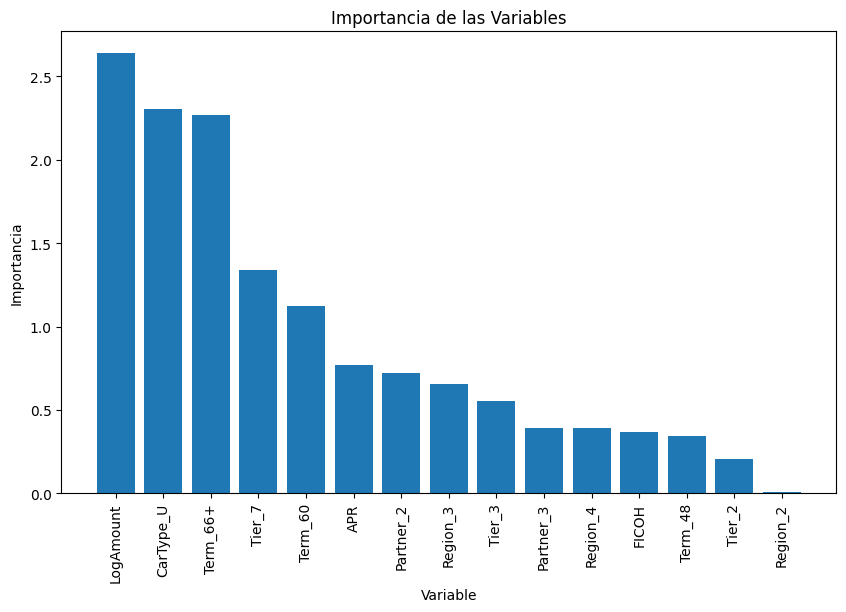

In [167]:
# Calcular la importancia de las variables
importancia_variables = abs(modelo_orig.coef_[0])
# Visualizar la importancia de las variables
import pandas as pd
data = {'Variable': X_train[variables_ind].columns, 'Importancia': importancia_variables}
df_importancia = pd.DataFrame(data)
# Ordenar el DataFrame por importancia de manera descendente
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)
# Visualizar el gráfico de barras en vertical
plt.figure(figsize=(10, 6))
plt.bar(df_importancia['Variable'], df_importancia['Importancia'])
plt.xticks(rotation=90)
plt.title('Importancia de las Variables')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.show()

In [168]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
# Obtener los coeficientes absolutos del modelo
coef = modelo_orig.coef_[0]  # El coeficiente de cada variable
coef_abs = abs(coef)    # Magnitud de los coeficientes
# Calcular el porcentaje de importancia
coef_percentage = (coef_abs / coef_abs.sum()) * 100
# Crear un DataFrame para mostrar las variables y su porcentaje de importancia
importancia = pd.DataFrame({'Variable': X_train[variables_ind].columns, 'Importancia (%)': coef_percentage})

# Ordenar por importancia en orden descendente
importancia_ordenada = importancia.sort_values(by='Importancia (%)', ascending=False)
print(importancia_ordenada)


     Variable  Importancia (%)
13  LogAmount        18.736684
8   CarType_U        16.384524
7    Term_66+        16.130544
2      Tier_7         9.530619
6     Term_60         7.973988
14        APR         5.449449
3   Partner_2         5.121872
10   Region_3         4.654450
1      Tier_3         3.943348
4   Partner_3         2.802293
11   Region_4         2.764601
12      FICOH         2.591873
5     Term_48         2.423465
0      Tier_2         1.452915
9    Region_2         0.039375


# 10. Importancia relativa de variables y lectura económica de coeficientes

Bajo el criterio de importancia relativa utilizado en el notebook, calculado a partir de la magnitud absoluta de los coeficientes, las variables con mayor peso relativo son `LogAmount` (18.74%), `CarType_U` (16.38%), `Term_66+` (16.13%), `Tier_7` (9.53%), `Term_60` (7.97%) y `APR` (5.45%).

Esta importancia representa asociación histórica dentro del modelo y no implica causalidad. Ademas, al estar basada en coeficientes, puede depender de la escala de las variables. Por eso debe leerse como una guía interpretativa del modelo, no como una verdad absoluta de negocio.

La lectura para pricing es qué la propensión de aceptación no depende solo de la tasa. Tambien se relaciona con monto, tipo de vehículo, plazo, segmento de riesgo y canal, lo qué respalda estrategias diferenciadas por perfil.


In [169]:
modelo_orig.coef_

array([[ 0.20454094,  0.5551435 ,  1.34171795, -0.7210557 , -0.39450604,
         0.34117473,  1.12257593,  2.2708537 ,  2.30660883,  0.00554324,
         0.65525227,  0.38919972, -0.36488316, -2.63774529, -0.76717199]])

In [170]:
modelo_orig.intercept_

array([26.6671022])

### Signo de coeficientes y lectura económica

Los coeficientes con signo permiten interpretar la dirección del efecto sobre el log-odds de aceptación, manteniendo constantes las variables incluidas. `APR` tiene coeficiente negativo (-0.7672), consistente con el trade-off de pricing: tasas más altas tienden a reducir la probabilidad de adquisición.

`LogAmount` también presenta coeficiente negativo (-2.6377), mientras qué algunas dummies como `CarType_U`, `Term_66+`, `Tier_7` y `Term_60` tienen coeficientes positivos frente a sus categorías base. Esta interpretación es asociativa y no causal; captura patrones historicos de aceptación dentro de la base aprobada.


# 11. Evaluación técnica del modelo en test


In [171]:
from sklearn.metrics import recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score

In [172]:
variables_ind = ['Tier_2', 'Tier_3', 'Tier_7', 'Partner_2','Partner_3',
                 'Term_48', 'Term_60', 'Term_66+',
                 'CarType_U',
                 'Region_2', 'Region_3', 'Region_4',
                 'FICOH', 'LogAmount', 'APR']

In [173]:
### MODELO ORIGINAL
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

In [174]:
# Predicción para ejemplos no vistos
y_pred = modelo_orig.predict(X_test[variables_ind])
y_pred = list(map(round, y_pred))
y_pred[:5]

[1, 0, 0, 0, 1]

In [175]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [176]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[24432   838]
 [ 2574  2749]]


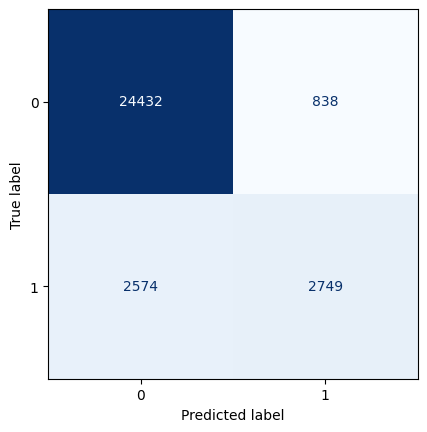

In [177]:
# Evaluación del modelo
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', colorbar=False);

In [178]:
# Métricas del modelo
print('Accuracy: ', accuracy_score(y_test, y_pred)) # Exactitud general
print('Precision: ', precision_score(y_test, y_pred)) # % de predicciones positivas correctas
print('Recall (sensibilidad): ', recall_score(y_test, y_pred)) # % de verdaderos positivos

Accuracy:  0.8884712189062858
Precision:  0.7663785893504321
Recall (sensibilidad):  0.5164380988164569


### Interpretación de desempeño en test

En la muestra de prueba, la matriz de confusión muestra 24,432 verdaderos negativos, 838 falsos positivos, 2,574 falsos negativos y 2,749 verdaderos positivos. El accuracy es 0.8885, la precisión 0.7664 y el recall 0.5164.

Como `Funded = 1` representa aproximadamente 17.21% de la base, un baseline qué predijera siempre no aceptación tendría un accuracy cercano a 82.79%. Por eso, el accuracy debe leerse con cautela.

Para negocio, esto significa qué cuando el modelo predice aceptación, acierta con una precisión relativamente alta. Sin embargo, con umbral 0.5 identifica aproximadamente la mitad de los clientes qué efectivamente aceptan. En pricing, el valor principal no es la clasificación final 0/1, sino ordenar clientes por probabilidad de aceptación y alimentar la simulación de tasas.


### Interpretación de métricas de clasificación

Las métricas se leen desde la perspectiva de adquisición del crédito:

1. `Precision`: de las solicitudes qué el modelo predice como aceptadas (`Funded = 1`), qué proporción efectivamente se financia.
2. `Recall`: de todas las solicitudes qué realmente se financiaron, qué proporción logra identificar el modelo.
3. `Accuracy`: proporción total de aciertos, aunque debe interpretarse con cuidado por el desbalance de la clase positiva.

Estas métricas permanecen como evaluación técnica del modelo. No se presentan como KPIs principales de negocio para Pricing/CRM.


In [179]:
# Genera probabilidades utilizando el modelo
proba_modelo_orig = modelo_orig.predict_proba(X_test[variables_ind])[:, 1]
proba_modelo_orig

array([0.54812392, 0.12571539, 0.07620554, ..., 0.63755647, 0.02073103,
       0.01956737], shape=(30593,))

# 12. Curva ROC y utilidad del ranking de probabilidades


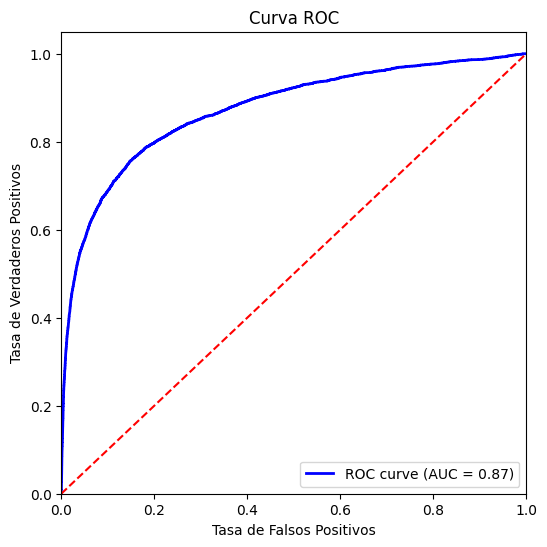

AUC: 0.873094914580617


In [180]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt
# Supongamos que proba.modelo_orig son las probabilidades del modelo original en Python
# y que imbal_testing es tu conjunto de prueba en Python
# Calcula el AUC y las tasas de falsos positivos y verdaderos positivos
fpr, tpr, thresholds = roc_curve(y_test, proba_modelo_orig)
# Calcula el AUC
auc1 = auc(fpr, tpr)
# Grafica la curva ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = {:.2f})'.format(auc1))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()
print("AUC:", auc1)

### Curva ROC y utilidad del ranking

El AUC de 0.8731 indica buena capacidad de ordenamiento entre solicitudes qué aceptan y no aceptan la oferta. Para pricing, está métrica es útil porque valida qué la probabilidad estimada contiene información para rankear clientes por propensión de adquisición.

Aún asi, el AUC no responde por si solo qué tasa ofrecer. La decisión de tasa requiere combinar la probabilidad de aceptación con el spread esperado, qué es lo qué se desarrolla en el bloque de optimización.


# BLOQUE B: Optimización de tasa

## 13. Preparacion de probabilidades estimadas para optimización

En está etapa se utiliza el modelo de propensión para simular como cambia la probabilidad de aceptación ante distintos niveles de tasa. La optimización no busca maximizar solo conversión ni solo tasa: busca el punto donde el producto entre margen aproximado y probabilidad de aceptación genera mayor rentabilidad esperada.

El margen se aproxima mediante `Spread = APR - PrimeRate`. Esta aproximación captura una diferencia financiera simple entre tasa ofrecida y tasa de referencia, pero no incorpora pérdida esperada, costo operativo, costo de capital, prepagos, mora ni recuperaciones. Por lo tanto, debe leerse como una primera aproximación de margen financiero, no como utilidad contable completa.


In [181]:
modelo_orig

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [182]:
modelo_orig.coef_

array([[ 0.20454094,  0.5551435 ,  1.34171795, -0.7210557 , -0.39450604,
         0.34117473,  1.12257593,  2.2708537 ,  2.30660883,  0.00554324,
         0.65525227,  0.38919972, -0.36488316, -2.63774529, -0.76717199]])

In [183]:
modelo_orig.intercept_

array([26.6671022])

In [184]:
X_test.head()

,FICO,FICOH,LogAmount,APR,PrimeRate,Spread,Tier,Partner,Term,CarType,...,Tier_7,Partner_2,Partner_3,CarType_U,Term_48,Term_60,Term_66+,Region_2,Region_3,Region_4
4956,764,-0.01,9.946087,5.64,1.8200,3.8200,1,1,60,U,...,0,0,0,1,0,1,0,0,1,0
44778,798,0.33,9.946169,4.39,1.2800,3.1100,1,3,60,N,...,0,0,1,0,0,1,0,0,0,1
121601,784,0.19,10.434116,3.85,1.0900,2.7600,1,3,60,N,...,0,0,1,0,0,1,0,0,1,0
34530,777,0.12,10.154830,4.55,1.3400,3.2100,1,3,60,N,...,0,0,1,0,0,1,0,0,0,1
41502,664,0.08,8.853665,7.89,1.3375,6.5525,7,1,60,U,...,1,0,0,1,0,1,0,0,0,0


In [185]:
## Se agrega las variables de fondeo y spread para generar la curva de margen
data_test = pd.merge(X_test[variables_ind], X_test[['PrimeRate', 'Spread']], left_index=True, right_index=True, how='inner')


In [186]:
data_test.head()

,Tier_2,Tier_3,Tier_7,Partner_2,Partner_3,Term_48,Term_60,Term_66+,CarType_U,Region_2,Region_3,Region_4,FICOH,LogAmount,APR,PrimeRate,Spread
4956,0,0,0,0,0,0,1,0,1,0,1,0,-0.01,9.946087,5.64,1.8200,3.8200
44778,0,0,0,0,1,0,1,0,0,0,0,1,0.33,9.946169,4.39,1.2800,3.1100
121601,0,0,0,0,1,0,1,0,0,0,1,0,0.19,10.434116,3.85,1.0900,2.7600
34530,0,0,0,0,1,0,1,0,0,0,0,1,0.12,10.154830,4.55,1.3400,3.2100
41502,0,0,1,0,0,0,1,0,1,0,0,0,0.08,8.853665,7.89,1.3375,6.5525


In [187]:
# Genera probabilidades utilizando el modelo
proba_modelo_orig = modelo_orig.predict_proba(data_test[variables_ind])[:, 1]
proba_modelo_orig

array([0.54812392, 0.12571539, 0.07620554, ..., 0.63755647, 0.02073103,
       0.01956737], shape=(30593,))

In [188]:
data_test['Probabilidad'] = proba_modelo_orig

In [189]:
data_test.head()

,Tier_2,Tier_3,Tier_7,Partner_2,Partner_3,Term_48,Term_60,Term_66+,CarType_U,Region_2,Region_3,Region_4,FICOH,LogAmount,APR,PrimeRate,Spread,Probabilidad
4956,0,0,0,0,0,0,1,0,1,0,1,0,-0.01,9.946087,5.64,1.8200,3.8200,0.548124
44778,0,0,0,0,1,0,1,0,0,0,0,1,0.33,9.946169,4.39,1.2800,3.1100,0.125715
121601,0,0,0,0,1,0,1,0,0,0,1,0,0.19,10.434116,3.85,1.0900,2.7600,0.076206
34530,0,0,0,0,1,0,1,0,0,0,0,1,0.12,10.154830,4.55,1.3400,3.2100,0.073379
41502,0,0,1,0,0,0,1,0,1,0,0,0,0.08,8.853665,7.89,1.3375,6.5525,0.881019


### Probabilidades estimadas para optimización

`data_test` combina variables del modelo con `PrimeRate`, `Spread` y la probabilidad estimada de aceptación. En los primeros registros se observan probabilidades heterogeneas, por ejemplo 0.5481, 0.1257, 0.0762, 0.0734 y 0.8810. Esta variabilidad es la base de una estrategia de tasa diferenciada.

El objetivo no es asignar la misma APR a todos los clientes, sino simular como cambia la probabilidad de aceptación para cada perfil cuando se mueve la tasa.


In [190]:
##Se recetean los indices para tener una tabla ordenada
data_test.reset_index(drop=True, inplace=True)


In [191]:
data_test.head()

,Tier_2,Tier_3,Tier_7,Partner_2,Partner_3,Term_48,Term_60,Term_66+,CarType_U,Region_2,Region_3,Region_4,FICOH,LogAmount,APR,PrimeRate,Spread,Probabilidad
0,0,0,0,0,0,0,1,0,1,0,1,0,-0.01,9.946087,5.64,1.8200,3.8200,0.548124
1,0,0,0,0,1,0,1,0,0,0,0,1,0.33,9.946169,4.39,1.2800,3.1100,0.125715
2,0,0,0,0,1,0,1,0,0,0,1,0,0.19,10.434116,3.85,1.0900,2.7600,0.076206
3,0,0,0,0,1,0,1,0,0,0,0,1,0.12,10.154830,4.55,1.3400,3.2100,0.073379
4,0,0,1,0,0,0,1,0,1,0,0,0,0.08,8.853665,7.89,1.3375,6.5525,0.881019


In [192]:
## Se genera una lista de precios para ver la curva de probabilidades y margenes
tasas = np.linspace(0.5, 15, 200).round(2)

## Se define un diccionario con los valores el intercepto y coeficientes del modelo
intercepto = 26.6445958
coeficientes = {
    'Tier_2': 0.20224792,
    'Tier_3': 0.5556858,
    'Tier_7': 1.33350885,
    'Partner_2': -0.71960037,
    'Partner_3': -0.39356969,
    'Term_48': 0.34459231,
    'Term_60': 1.1213783,
    'Term_66+': 2.26916519,
    'CarType_U': 2.30491015,
    'Region_2': 0.00330491,
    'Region_3': 0.65413868,
    'Region_4': 0.3869794,
    'FICOH': -0.36308223,
    'LogAmount': -2.63586375,
    'APR': -0.76585549
}


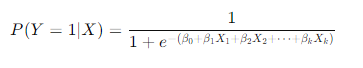


In [193]:
# Función para calcular las probabilidades de aceptación usando solo los coeficientes y variables del archivo
def calcular_probabilidad_fila(fila):
    # Calcular el logit sumando el intercepto y los coeficientes con las variables estandarizadas de la fila
    logit_base = intercepto
    for variable, coef in coeficientes.items():
        logit_base += coef * fila[variable]
    # Convertir el logit a probabilidades usando la función logística
    probabilidad = 1 / (1 + np.exp(-logit_base))
    return probabilidad
# Aplicar el cálculo de probabilidades para cada fila en el DataFrame
data_test['Probabilidad2'] = data_test.apply(lambda fila: calcular_probabilidad_fila(fila), axis=1)
# Mostrar las primeras probabilidades calculadas
data_test.head()

,Tier_2,Tier_3,Tier_7,Partner_2,Partner_3,Term_48,Term_60,Term_66+,CarType_U,Region_2,Region_3,Region_4,FICOH,LogAmount,APR,PrimeRate,Spread,Probabilidad,Probabilidad2
0,0,0,0,0,0,0,1,0,1,0,1,0,-0.01,9.946087,5.64,1.8200,3.8200,0.548124,0.548026
1,0,0,0,0,1,0,1,0,0,0,0,1,0.33,9.946169,4.39,1.2800,3.1100,0.125715,0.125726
2,0,0,0,0,1,0,1,0,0,0,1,0,0.19,10.434116,3.85,1.0900,2.7600,0.076206,0.076287
3,0,0,0,0,1,0,1,0,0,0,0,1,0.12,10.154830,4.55,1.3400,3.2100,0.073379,0.073401
4,0,0,1,0,0,0,1,0,1,0,0,0,0.08,8.853665,7.89,1.3375,6.5525,0.881019,0.880344


In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Función para calcular las probabilidades para una fila específica

def calcular_probabilidades_fila(fila, tasas):
    # Calcular el logit sumando el intercepto y los coeficientes con las variables estandarizadas de la fila
    logit_base = intercepto
    for variable, coef in coeficientes.items():
        if variable != 'APR':  # Mantener constantes todas las variables excepto la tasa
            logit_base += coef * fila[variable]
    # Calcular los logits variando solo la tasa
    logits = logit_base + coeficientes['APR'] * tasas
    # Convertir los logits a probabilidades usando la función logística
    probabilidades = 1 / (1 + np.exp(-logits))
    return probabilidades




In [195]:
# Aplicar el cálculo de probabilidades en función del rango de tasas para cada fila
data_test['Probabilidades'] = data_test.apply(lambda fila: calcular_probabilidades_fila(fila, tasas), axis=1)
data_test.head()

,Tier_2,Tier_3,Tier_7,Partner_2,Partner_3,Term_48,Term_60,Term_66+,CarType_U,Region_2,Region_3,Region_4,FICOH,LogAmount,APR,PrimeRate,Spread,Probabilidad,Probabilidad2,Probabilidades
0,0,0,0,0,0,0,1,0,1,0,1,0,-0.01,9.946087,5.64,1.8200,3.8200,0.548124,0.548026,"[0.9841591471388708, 0.9833013130637831, 0.982..."
1,0,0,0,0,1,0,1,0,0,0,0,1,0.33,9.946169,4.39,1.2800,3.1100,0.125715,0.125726,"[0.738829235353972, 0.7283530156543994, 0.7160..."
2,0,0,0,0,1,0,1,0,0,0,1,0,0.19,10.434116,3.85,1.0900,2.7600,0.076206,0.076287,"[0.5179228454639978, 0.5045279329655462, 0.489..."
3,0,0,0,0,1,0,1,0,0,0,0,1,0.12,10.154830,4.55,1.3400,3.2100,0.073379,0.073401,"[0.6378716892116891, 0.6253990654776268, 0.610..."
4,0,0,1,0,0,0,1,0,1,0,0,0,0.08,8.853665,7.89,1.3375,6.5525,0.881019,0.880344,"[0.9995267261656765, 0.999500674607726, 0.9994..."


# 14. Simulación de tasas y sensibilidad de aceptación

La simulación evalúa una grilla de tasas entre 0.5 y 15.0. Para cada solicitud se recalcula la probabilidad de aceptación usando el coeficiente de `APR` y el resto de variables del perfil.

El APR histórico observado va aproximadamente de 2.45% a 13.90%. Por lo tanto, los resultados dentro de ese rango histórico son más confiables; las tasas simuladas fuera de ese rango deben interpretarse como extrapolación.

Esta etapa traduce el modelo logístico en una herramienta de pricing: permite observar la sensibilidad de la probabilidad ante cambios de tasa y preparar el cálculo de rentabilidad esperada.


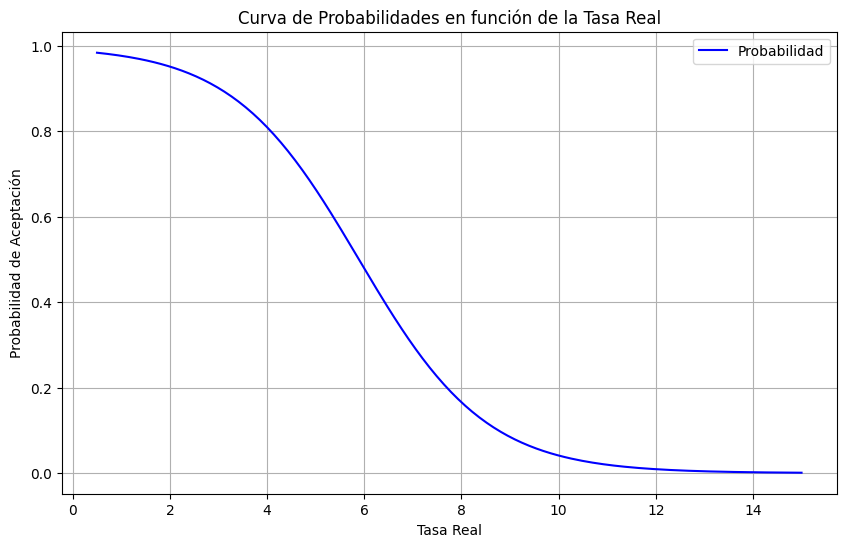

In [196]:
fila_ejemplo = data_test.iloc[0]
probabilidades_ejemplo = calcular_probabilidades_fila(fila_ejemplo, tasas)

# Graficar la curva de probabilidades
plt.figure(figsize=(10, 6))
plt.plot(tasas, probabilidades_ejemplo, label='Probabilidad', color='blue')
plt.title('Curva de Probabilidades en función de la Tasa Real')
plt.xlabel('Tasa Real')
plt.ylabel('Probabilidad de Aceptación')
plt.grid(True)
plt.legend()
plt.show()

# 15. Curva de probabilidad de aceptación

La curva del registro de ejemplo muestra la relación esperada entre tasa y probabilidad de aceptación: al aumentar la tasa, la probabilidad cae. Esta forma es consistente con el coeficiente negativo de `APR` y con la lógica comercial de disposición a pagar.

En términos de negocio, bajar la tasa puede mejorar conversión, pero no necesariamente maximiza margen. Por eso se requiere el siguiente paso: combinar probabilidad y spread.


In [197]:
# Función para calcular el profit (margen)
def calcular_profit(probabilidades, tasas, fila):
    FONDEO = fila['PrimeRate']
    SPREAD = (tasas - FONDEO) * np.array(probabilidades)
    Prob_min = np.min(probabilidades)
    Prob_max = np.max(probabilidades)
    return SPREAD, Prob_min, Prob_max

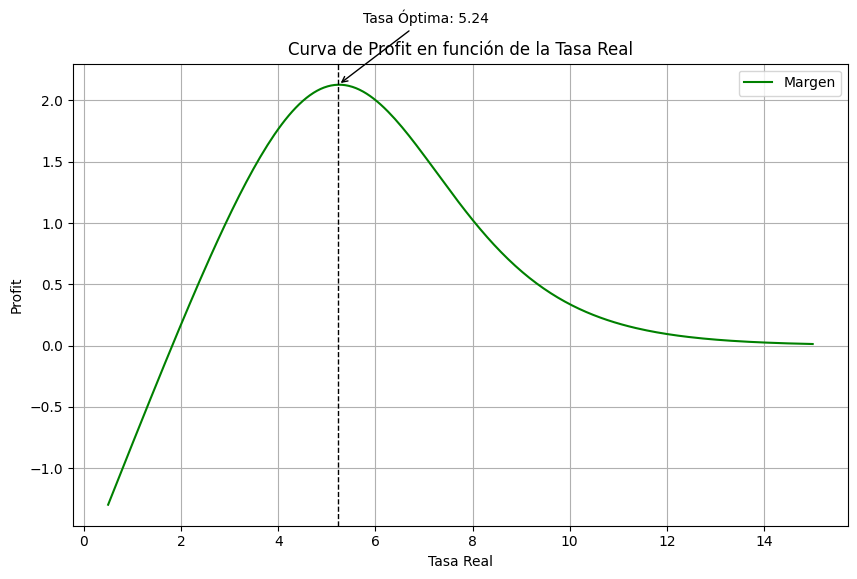

In [198]:
Margen_ejemplo = calcular_profit(probabilidades_ejemplo, tasas, fila_ejemplo)

# Encontrar la tasa que optimiza el profit
tasa_optima_idx = np.argmax(Margen_ejemplo[0])
tasa_optima = tasas[tasa_optima_idx]
SPREAD_maximo = Margen_ejemplo[0][tasa_optima_idx]

# Graficar la curva de profit y la tasa óptima
plt.figure(figsize=(10, 6))
plt.plot(tasas, Margen_ejemplo[0], label='Margen', color='green')
plt.axvline(x=tasa_optima, color='black', linestyle='--', linewidth=1)
plt.annotate(f'Tasa Óptima: {tasa_optima:.2f}', xy=(tasa_optima, SPREAD_maximo),
             xytext=(tasa_optima + 0.5, SPREAD_maximo + 0.5),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             color='black')
plt.title('Curva de Profit en función de la Tasa Real')
plt.xlabel('Tasa Real')
plt.ylabel('Profit')
plt.grid(True)
plt.legend()
plt.show()

# 16. Curva de profit aproximado y tasa óptima

La curva de profit combina dos componentes: el spread financiero aproximado (`tasa - PrimeRate`) y la probabilidad de aceptación estimada. La tasa óptima aparece donde ese producto alcanza su máximo.

En forma simplificada: `Profit aproximado ≈ (tasa - PrimeRate) × probabilidad de aceptación`. Esta es una aproximación basada en spread. En una implementación bancaria completa deberían incorporarse pérdida esperada, costo operativo, costo de capital, mora, recuperaciones, prepagos y otros componentes financieros.

Esta visualización resume el trade-off central de pricing: tasas muy bajas pueden tener alta aceptación pero bajo margen; tasas muy altas pueden tener mayor spread unitario pero menor probabilidad de adquisición.


In [199]:
# Parte 3: Cálculo de la tasa óptima y profit máximo para todas las filas
resultados_optimos = []
beta_apr = coeficientes['APR']
for index, fila in data_test.iterrows():
    if pd.isnull(fila['LogAmount']): # Si la condición es True se utiliza continue para omitir el resto del código.
        continue
    probabilidades = calcular_probabilidades_fila(fila, tasas)
    SPREAD, Prob_min, Prob_max = calcular_profit(probabilidades, tasas, fila)

    # Encontrar la tasa óptima que maximiza el SPREAD
    tasa_optima_idx = np.argmax(SPREAD) ## np.argmax(SPREAD): Encuentra el índice del valor máximo en el array SPREAD
    tasa_optima = tasas[tasa_optima_idx]
    SPREAD_maximo = SPREAD[tasa_optima_idx]
    probabilidad_optima = probabilidades[tasa_optima_idx]

    elasticidad_opt  = beta_apr * tasa_optima * (1 - probabilidad_optima)
    # Almacenar resultados
    resultados_optimos.append({
        'Tasa_Opt': tasa_optima,
        'Margen_Maximo': SPREAD_maximo,
        'Prob_Opt': probabilidad_optima,
        'Prob_Min': Prob_min,
        'Prob_Max': Prob_max,
        'Elasticidad_Opt': elasticidad_opt
    })

In [200]:
# Crear un DataFrame con los resultados óptimos
df_resultados_optimos = pd.DataFrame(resultados_optimos)
df_resultados_optimos


,Tasa_Opt,Margen_Maximo,Prob_Opt,Prob_Min,Prob_Max,Elasticidad_Opt
0,5.24,2.128040,0.622234,0.000933,0.984159,-1.516007
1,3.12,0.507010,0.275549,0.000043,0.738829,-1.731053
2,2.69,0.267543,0.167214,0.000016,0.517923,-1.715665
3,2.98,0.342159,0.208633,0.000026,0.637872,-1.806096
4,8.52,5.886312,0.819535,0.030783,0.999527,-1.177548
...,...,...,...,...,...,...
30588,2.90,0.494084,0.277576,0.000036,0.707140,-1.604491
30589,2.83,0.425939,0.249087,0.000030,0.663952,-1.627506
30590,5.60,2.455499,0.653058,0.001405,0.989422,-1.487961
30591,3.41,0.976876,0.433089,0.000107,0.876466,-1.480525


# 17. Resultados óptimos por solicitud o segmento

`df_resultados_optimos` resume, para cada solicitud de la muestra de prueba, la tasa qué maximiza el profit aproximado bajo los supuestos del modelo. Incluye `Tasa_Opt`, `Margen_Maximo`, `Prob_Opt`, `Prob_Min`, `Prob_Max` y `Elasticidad_Opt`.

Este resultado puede analizarse por solicitud o agregarse por segmentos como `Tier`, `Term`, `CarType`, `Partner` o `Region` para construir reglas de negocio, bandas de tasa o grupos candidatos para pilotos.


In [201]:
# Unir los DataFrames para crear el DataFrame final
df_modelo_wtp_final = pd.merge(data_test, df_resultados_optimos, left_index=True, right_index=True, how='inner')

# Mostrar el DataFrame final para confirmar que se unió correctamente
df_modelo_wtp_final.head()

,Tier_2,Tier_3,Tier_7,Partner_2,Partner_3,Term_48,Term_60,Term_66+,CarType_U,Region_2,...,Spread,Probabilidad,Probabilidad2,Probabilidades,Tasa_Opt,Margen_Maximo,Prob_Opt,Prob_Min,Prob_Max,Elasticidad_Opt
0,0,0,0,0,0,0,1,0,1,0,...,3.8200,0.548124,0.548026,"[0.9841591471388708, 0.9833013130637831, 0.982...",5.24,2.128040,0.622234,0.000933,0.984159,-1.516007
1,0,0,0,0,1,0,1,0,0,0,...,3.1100,0.125715,0.125726,"[0.738829235353972, 0.7283530156543994, 0.7160...",3.12,0.507010,0.275549,0.000043,0.738829,-1.731053
2,0,0,0,0,1,0,1,0,0,0,...,2.7600,0.076206,0.076287,"[0.5179228454639978, 0.5045279329655462, 0.489...",2.69,0.267543,0.167214,0.000016,0.517923,-1.715665
3,0,0,0,0,1,0,1,0,0,0,...,3.2100,0.073379,0.073401,"[0.6378716892116891, 0.6253990654776268, 0.610...",2.98,0.342159,0.208633,0.000026,0.637872,-1.806096
4,0,0,1,0,0,0,1,0,1,0,...,6.5525,0.881019,0.880344,"[0.9995267261656765, 0.999500674607726, 0.9994...",8.52,5.886312,0.819535,0.030783,0.999527,-1.177548


# 18. Dataset final de pricing / propensión estimada

El resultado final `df_modelo_wtp_final` une el perfil de cada solicitud con su `Tasa_Opt`, `Margen_Maximo`, `Prob_Opt`, `Prob_Min`, `Prob_Max` y `Elasticidad_Opt`. En los primeros cinco casos, la tasa óptima varia entre 2.69 y 8.52, lo qué confirma qué la recomendación debe ser individual o segmentada, no una regla única de tasa.

Aunque el nombre del dataset contiene `wtp`, en este caso no debe interpretarse como una medición directa de willingness to pay. La disposición a aceptar la tasa se infiere desde comportamiento histórico de aceptación/no aceptación, no desde encuestas ni métodos directos como Van Westendorp.


# 19. KPIs de negocio sugeridos para seguimiento de Pricing y CRM

Estos KPIs son accionables para Pricing y CRM/canales. No reemplazan las métricas técnicas del modelo; AUC, precisión, recall y accuracy permanecen en la sección de evaluación técnica.

- **Tasa de aceptación esperada:** probabilidad promedio de aceptación por segmento.
- **APR óptima promedio:** tasa recomendada promedio por segmento.
- **Spread esperado:** APR óptima menos `PrimeRate`.
- **Profit esperado aproximado:** spread esperado × probabilidad de aceptación.
- **Brecha APR actual vs APR óptima:** diferencia entre la tasa histórica/ofrecida y la tasa recomendada.
- **Volumen potencial de aceptación:** cantidad esperada de solicitudes aceptadas según probabilidad estimada.
- **Segmentos prioritarios para piloto:** combinaciones de `Tier`, `Term`, `CarType`, `Partner` o `Region` con mejor balance entre probabilidad y margen.

Si estos KPIs no están calculados explícitamente en el notebook, deben entenderse como KPIs sugeridos para implementación futura usando las columnas disponibles en `df_modelo_wtp_final`.


# 20. Recomendaciones de uso para pilotos o campañas

El output puede ser utilizado por Pricing para definir bandas de tasa y por CRM/canales para priorizar campañas o pilotos controlados. Una aplicación práctica sería agrupar clientes por segmentos de negocio, comparar APR histórica contra APR óptima y seleccionar grupos donde exista un balance atractivo entre aceptación esperada y margen aproximado.

La implementación comercial no debería escalarse de forma automática. La tasa óptima estimada debe validarse con piloto/control, monitoreo por segmento y restricciones de política comercial, riesgo y regulación.


# 21. Limitaciones

El modelo estima probabilidad de aceptación/adquisición, no riesgo de incumplimiento ni probabilidad de default. `Tier` y `FICO` aportan información crediticia, pero no reemplazan un modelo de pérdida esperada.

El spread usado es una aproximación de margen financiero y no incluye pérdida esperada, costo operativo, costo de capital, mora, prepagos, recuperaciones ni otros componentes financieros. Por ello, `Margen_Maximo` debe interpretarse como rentabilidad esperada simplificada.

La simulación de tasa aprende asociaciones históricas, no causalidad. La tasa óptima estimada debería validarse con piloto/control antes de escalarse comercialmente.

El resultado es una herramienta de apoyo para pricing y CRM, no una regla automática de aprobación, rechazo ni desembolso.


# 22. Conclusiones e insights de negocio

**1. La aprobación crediticia no garantiza adquisición.**
La base muestra una tasa de aceptación cercana al 17.2%, lo que evidencia que, aun cuando una solicitud ya fue aprobada, la decisión final del cliente depende de la oferta recibida, especialmente de la tasa y de las condiciones del crédito.

**2. El modelo debe interpretarse como propensión a la aceptación, no como riesgo crediticio.**
La regresión logística estima la probabilidad de que el cliente acepte o financie el crédito. No modela aprobación, default ni pérdida esperada, ya que el análisis parte de solicitudes previamente aprobadas.

**3. La tasa APR tiene una relación económica consistente con la aceptación.**
El coeficiente negativo de `APR` confirma la lógica esperada de pricing: tasas más altas tienden a reducir la probabilidad de adquisición. Sin embargo, la aceptación no depende únicamente de la tasa, sino también de variables como monto, plazo, tipo de vehículo y segmento de riesgo.

**4. El modelo tiene utilidad para ordenar clientes por probabilidad de adquisición.**
El AUC de 0.8731 en test indica una buena capacidad para rankear solicitudes según su propensión de aceptación. Esto es relevante para pricing porque permite simular escenarios de tasa y priorizar segmentos con mayor probabilidad de conversión.

**5. La optimización traduce la probabilidad en una decisión económica.**
La tasa óptima no busca maximizar solo la tasa ni solo la conversión, sino equilibrar spread y probabilidad de aceptación. En este notebook, la rentabilidad esperada se aproxima mediante `Spread × probabilidad de aceptación`.

**6. La recomendación de tasa debe ser diferenciada por perfil.**
Los resultados muestran que no conviene aplicar una única tasa para todos los clientes. La tasa recomendada depende del perfil del cliente, el plazo, el tipo de vehículo, el segmento de riesgo y el contexto de fondeo (`PrimeRate`).

**7. El output final puede alimentar acciones de Pricing y CRM.**
La matriz exportable permite convertir el modelo en un insumo accionable para revisar tasas, priorizar segmentos, diseñar pilotos y coordinar campañas comerciales. Antes de escalar una estrategia, la recomendación debería validarse mediante piloto/control y restricciones de riesgo, política comercial y regulación.

**8. El valor del proyecto está en conectar analítica, pricing y negocio.**
El proyecto integra EDA, modelo de propensión, margen financiero aproximado y optimización de tasa, manteniendo separada la lógica de pricing de la lógica de riesgo crediticio.


# Output accionable para Pricing y CRM

Esta seccion genera un Excel simple y visual para negocio a partir de `df_modelo_wtp_final`. El objetivo es que Pricing pueda revisar tasas y segmentos, y que CRM/canales pueda priorizar pilotos o campanas.

La salida se resume en tres hojas:

- `detalle_solicitudes`: detalle por solicitud.
- `matriz_segmentos`: tabla agregada por `Tier + Term + CarType`.
- `matriz_visual`: mapa 2x2 de priorizacion usando probabilidad de aceptacion y profit esperado aproximado.


In [202]:
# Output accionable para Pricing y CRM
# Version corta: detalle, matriz agregada y mapa visual 2x2.

import numpy as np
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# 1) Base accionable: resultados optimos + segmentos originales del test.
segmentacion = X_test[['Tier', 'Term', 'CarType', 'Partner', 'Region']].reset_index(drop=True)
df_out = pd.concat([segmentacion, df_modelo_wtp_final.reset_index(drop=True)], axis=1)

df_out = df_out.assign(
    solicitud_id=lambda x: x.index,
    **{
        'APR actual': df_out['APR'],
        'Spread actual': df_out['Spread'],
        'brecha APR': df_out['Tasa_Opt'] - df_out['APR'],
        'spread esperado': df_out['Tasa_Opt'] - df_out['PrimeRate'],
        'profit esperado aproximado': df_out['Margen_Maximo']
    }
)

# 2) Matriz por segmento Tier + Term + CarType.
matriz = df_out.groupby(['Tier', 'Term', 'CarType'], dropna=False).agg(
    n_solicitudes=('solicitud_id', 'count'),
    **{
        'APR actual promedio': ('APR actual', 'mean'),
        'APR optima promedio': ('Tasa_Opt', 'mean'),
        'brecha APR': ('brecha APR', 'mean'),
        'probabilidad aceptacion promedio': ('Prob_Opt', 'mean'),
        'spread esperado promedio': ('spread esperado', 'mean'),
        'profit esperado aproximado': ('profit esperado aproximado', 'mean'),
        'aceptaciones esperadas': ('Prob_Opt', 'sum')
    }
).reset_index()

prob_umbral = matriz['probabilidad aceptacion promedio'].median()
profit_umbral = matriz['profit esperado aproximado'].median()
prob_alta = matriz['probabilidad aceptacion promedio'] >= prob_umbral
profit_alto = matriz['profit esperado aproximado'] >= profit_umbral

matriz['cuadrante'] = np.select(
    [prob_alta & profit_alto, prob_alta & ~profit_alto, ~prob_alta & profit_alto],
    ['Alta probabilidad + alto profit', 'Alta probabilidad + bajo profit', 'Baja probabilidad + alto profit'],
    default='Baja probabilidad + bajo profit'
)
matriz['prioridad piloto'] = np.select([prob_alta & profit_alto, prob_alta | profit_alto], ['Alta', 'Media'], default='Baja')
matriz['accion sugerida'] = np.select(
    [prob_alta & profit_alto, prob_alta & ~profit_alto, ~prob_alta & profit_alto],
    ['Priorizar campana', 'Mantener / revisar margen', 'Testear ajuste de tasa'],
    default='No priorizar'
)
matriz = matriz.sort_values(['prioridad piloto', 'profit esperado aproximado'], ascending=[True, False])

# 3) Detalle por solicitud.
detalle = df_out[[
    'solicitud_id', 'Tier', 'Term', 'CarType', 'Partner', 'Region',
    'APR actual', 'PrimeRate', 'Spread actual', 'Tasa_Opt', 'Prob_Opt',
    'profit esperado aproximado', 'brecha APR'
]].merge(
    matriz[['Tier', 'Term', 'CarType', 'prioridad piloto', 'accion sugerida', 'cuadrante']],
    on=['Tier', 'Term', 'CarType'], how='left'
)

# 4) Exportar tablas.
output_path = 'output_pricing_crm_creditos_vehiculares.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    detalle.to_excel(writer, sheet_name='detalle_solicitudes', index=False)
    matriz.to_excel(writer, sheet_name='matriz_segmentos', index=False)

# 5) Crear matriz visual tipo cuadrantes.
wb = load_workbook(output_path)
ws = wb.create_sheet('matriz_visual', 0)

fills = {
    'verde': '6A8F35', 'verde_fuerte': '2E7D32',
    'naranja': 'F4B183', 'rojo': 'C00000',
    'gris': 'EDEDED', 'azul': '1F4E78'
}
white = 'FFFFFF'
border = Border(*(Side(style='thin', color=white),) * 4)

stats = matriz.groupby('cuadrante').agg(
    segmentos=('Tier', 'count'), solicitudes=('n_solicitudes', 'sum'),
    prob=('probabilidad aceptacion promedio', 'mean'), profit=('profit esperado aproximado', 'mean')
).to_dict('index')

def label(cuadrante, accion):
    s = stats.get(cuadrante, {'segmentos': 0, 'solicitudes': 0, 'prob': 0, 'profit': 0})
    return f'{accion}\n{int(s["segmentos"])} segmentos | {int(s["solicitudes"]):,} solicitudes\nProb: {s["prob"]:.1%}\nProfit: {s["profit"]:.2f}'

def bloque(rango, texto, color, font=white):
    ws.merge_cells(rango)
    c = ws[rango.split(':')[0]]
    c.value, c.fill = texto, PatternFill('solid', fgColor=color)
    c.font = Font(color=font, bold=True, size=12)
    c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    for row in ws[rango]:
        for cell in row:
            cell.fill = PatternFill('solid', fgColor=color)
            cell.border = border

ws.merge_cells('B2:F2')
ws['B2'] = 'Matriz visual de priorizacion Pricing / CRM'
ws['B2'].fill = PatternFill('solid', fgColor=fills['azul'])
ws['B2'].font = Font(color=white, bold=True, size=15)
ws['B2'].alignment = Alignment(horizontal='center')

ws.merge_cells('C4:F4'); ws['C4'] = 'Profit esperado aproximado'
ws['C5'], ws['E5'] = 'Profit bajo', 'Profit alto'
ws.merge_cells('A6:A13'); ws['A6'] = 'Probabilidad de aceptacion estimada'
ws.merge_cells('B6:B9'); ws['B6'] = 'Probabilidad alta'
ws.merge_cells('B10:B13'); ws['B10'] = 'Probabilidad baja'
for cell in ['C4', 'C5', 'E5', 'A6', 'B6', 'B10']:
    ws[cell].fill = PatternFill('solid', fgColor=fills['gris'])
    ws[cell].font = Font(bold=True, color='404040')
    ws[cell].alignment = Alignment(horizontal='center', vertical='center', wrap_text=True, text_rotation=90 if cell == 'A6' else 0)

bloque('C6:D9', label('Alta probabilidad + bajo profit', 'Mantener / revisar margen'), fills['naranja'], '000000')
bloque('E6:F9', label('Alta probabilidad + alto profit', 'Priorizar campana'), fills['verde_fuerte'])
bloque('C10:D13', label('Baja probabilidad + bajo profit', 'No priorizar'), fills['rojo'])
bloque('E10:F13', label('Baja probabilidad + alto profit', 'Testear ajuste de tasa'), fills['verde'], white)

ws['C15'] = 'Acciones sugeridas'
ws['C16'] = 'Priorizar campana | Mantener / revisar margen | Testear ajuste de tasa | No priorizar'
ws['C18'] = f'Umbral probabilidad: {prob_umbral:.1%}'
ws['C19'] = f'Umbral profit: {profit_umbral:.2f}'
ws['C20'] = 'Tasas expresadas en puntos porcentuales; se muestran con dos decimales.'

for col in ['A', 'B', 'C', 'D', 'E', 'F']:
    ws.column_dimensions[col].width = 19
for row in range(6, 14):
    ws.row_dimensions[row].height = 34
ws.sheet_view.showGridLines = False

# Formato minimo para hojas de tabla.
for sheet in ['detalle_solicitudes', 'matriz_segmentos']:
    sh = wb[sheet]
    sh.freeze_panes = 'A2'
    sh.auto_filter.ref = sh.dimensions
    for cell in sh[1]:
        cell.fill = PatternFill('solid', fgColor=fills['azul'])
        cell.font = Font(color=white, bold=True)
        cell.alignment = Alignment(horizontal='center', wrap_text=True)
    for col in sh.columns:
        sh.column_dimensions[get_column_letter(col[0].column)].width = min(max(len(str(col[0].value)) + 4, 12), 30)

wb.save(output_path)
print(f'Archivo generado: {output_path}')
print(f'Solicitudes exportadas: {len(detalle):,}')
print(f'Segmentos exportados: {len(matriz):,}')
print('Hoja visual creada: matriz_visual')


Archivo generado: output_pricing_crm_creditos_vehiculares.xlsx
Solicitudes exportadas: 30,593
Segmentos exportados: 32
Hoja visual creada: matriz_visual


### Interpretación del output exportado

* Se generó un archivo Excel con tres hojas: `matriz_visual`, `matriz_segmentos` y `detalle_solicitudes`. El objetivo es traducir los resultados del modelo y la optimización en un insumo accionable para negocio.

* La hoja `matriz_visual` resume la priorización de segmentos en una matriz 2x2, cruzando la probabilidad estimada de aceptación con el profit esperado aproximado. Esta vista permite identificar rápidamente qué grupos deberían priorizarse, monitorearse o validarse mediante piloto.

* La hoja `matriz_segmentos` presenta los KPIs agregados por segmento (`Tier`, `Term` y `CarType`), incluyendo APR actual promedio, APR óptima promedio, brecha de tasa, probabilidad de aceptación, spread esperado, profit esperado aproximado y aceptaciones esperadas.

* La hoja `detalle_solicitudes` contiene el resultado a nivel de solicitud, incluyendo tasa actual, tasa óptima estimada, probabilidad de aceptación, profit esperado aproximado, brecha APR y acción sugerida. Esta base podría servir como insumo operativo para campañas o pilotos controlados.

* Una brecha APR negativa indica que la tasa óptima estimada es menor que la tasa histórica/ofrecida. Esto puede interpretarse como una posible oportunidad para mejorar aceptación, siempre que el profit esperado aproximado siga siendo atractivo.

* La clasificación de prioridad se basa en umbrales internos de probabilidad de aceptación y profit esperado aproximado. Por ello, debe interpretarse como una herramienta de priorización, no como una regla automática de decisión.

* El output puede ser utilizado por Pricing para revisar estrategias de tasa y por CRM/canales para priorizar segmentos en campañas, pilotos o acciones comerciales diferenciadas.

* Antes de escalar cualquier recomendación, los resultados deberían validarse mediante piloto/control, considerando restricciones de riesgo, política comercial, regulación y rentabilidad completa.
